original data
1. EDA with statisical tests and plots
2. preprocessing (standard scaler, remove duplicates, one hot, label encoding, round all stupid values, feature selection?)
3. train test split
4. lazy predict
5. hyperparam tuning
6. xai

syntetic data
1. determine rows with high similiarity on real train set and remove
2. retrain and test with same config but augmented with syntetic
3. apply cross-val, nested cross-val maybe more?
4. compare results

final (optional)
1. add new features like bmi and ibw
2. test
3. compare

# Setup

In [1]:
!pip install ydata-profiling
!pip install lazypredict
!pip install catboost
!pip install ipywidgets
!pip install lazypredict==0.2.16
!pip install scikit-learn==1.4.2
!pip install shap
!pip install lime
!pip install scipy


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached scikit_learn-1.4.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available

In [5]:
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer

from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

import shap

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
real_data = pd.read_csv('/work/real-data.csv')

# EDA

## First Look

In [12]:
real_data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.00,1.62,64.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,0.00,1.00,no,Public_Transportation,Normal_Weight
1,Female,21.00,1.52,56.00,yes,no,3.00,3.00,Sometimes,yes,3.00,yes,3.00,0.00,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.00,1.80,77.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,2.00,1.00,Frequently,Public_Transportation,Normal_Weight
3,Male,27.00,1.80,87.00,no,no,3.00,3.00,Sometimes,no,2.00,no,2.00,0.00,Frequently,Walking,Overweight_Level_I
4,Male,22.00,1.78,89.80,no,no,2.00,1.00,Sometimes,no,2.00,no,0.00,0.00,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.98,1.71,131.41,yes,yes,3.00,3.00,Sometimes,no,1.73,no,1.68,0.91,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.98,1.75,133.74,yes,yes,3.00,3.00,Sometimes,no,2.01,no,1.34,0.60,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.52,1.75,133.69,yes,yes,3.00,3.00,Sometimes,no,2.05,no,1.41,0.65,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.36,1.74,133.35,yes,yes,3.00,3.00,Sometimes,no,2.85,no,1.14,0.59,Sometimes,Public_Transportation,Obesity_Type_III


In [15]:
real_data.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [18]:
real_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [21]:
profile = ProfileReport(real_data, title="Profiling Report - Real data")

In [27]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 172.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
# Remove duplicate rows from real_data_new
real_data_new = real_data.drop_duplicates().reset_index(drop=True)

## Plots: TODO: More plots with especially with target variable 

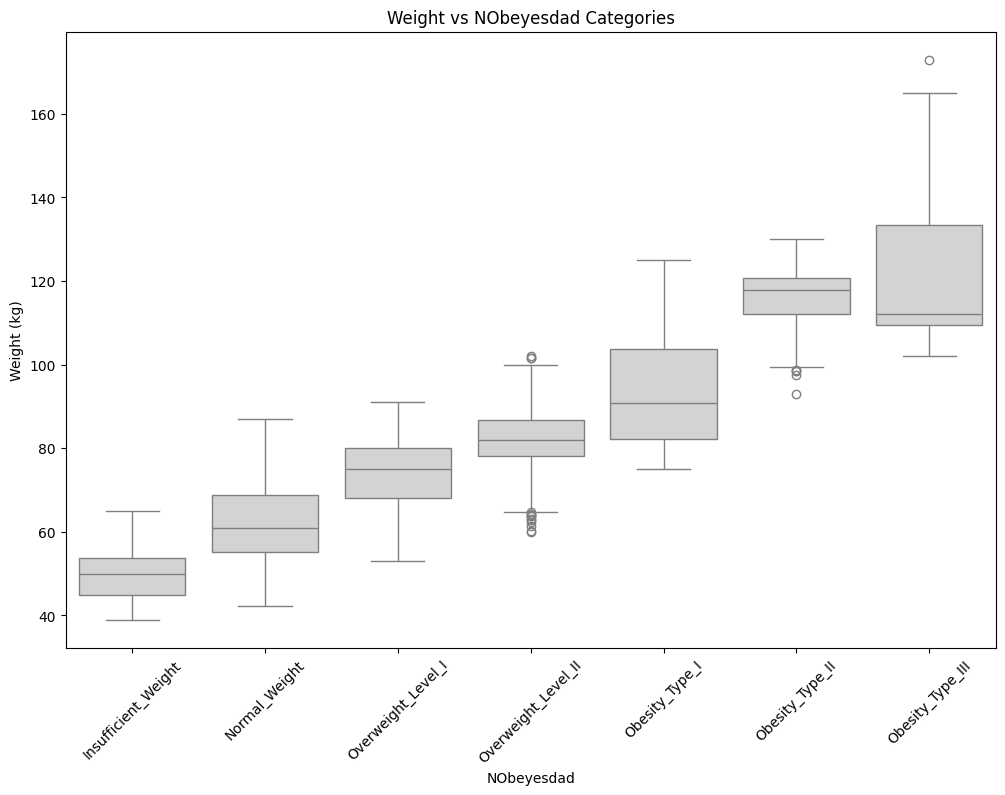

In [31]:
%matplotlib inline

# Manually specify the desired order of the NObeyesdad categories
ordered_categories = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

# Plotting with manually specified category order
plt.figure(figsize=(12, 8))
sns.boxplot(x='NObeyesdad', y='Weight', data=real_data_new, order=ordered_categories, color='lightgrey')
plt.title('Weight vs NObeyesdad Categories')
plt.ylabel('Weight (kg)')
plt.xticks(rotation=45)
plt.show()

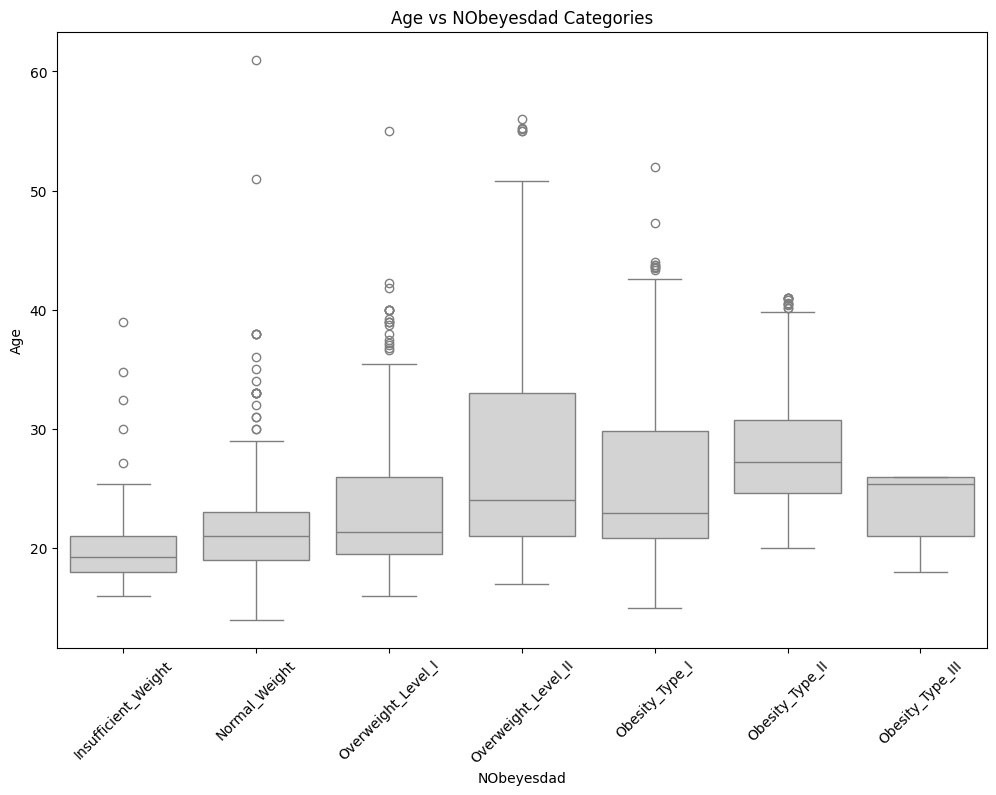

In [34]:
# Plotting with manually specified category order and setting the color to light grey
plt.figure(figsize=(12, 8))
sns.boxplot(x='NObeyesdad', y='Age', data=real_data_new, order=ordered_categories, color='lightgrey')
plt.title('Age vs NObeyesdad Categories')
plt.ylabel('Age')
plt.xticks(rotation=45)  # Rotating the x-axis labels for better readability
plt.show()

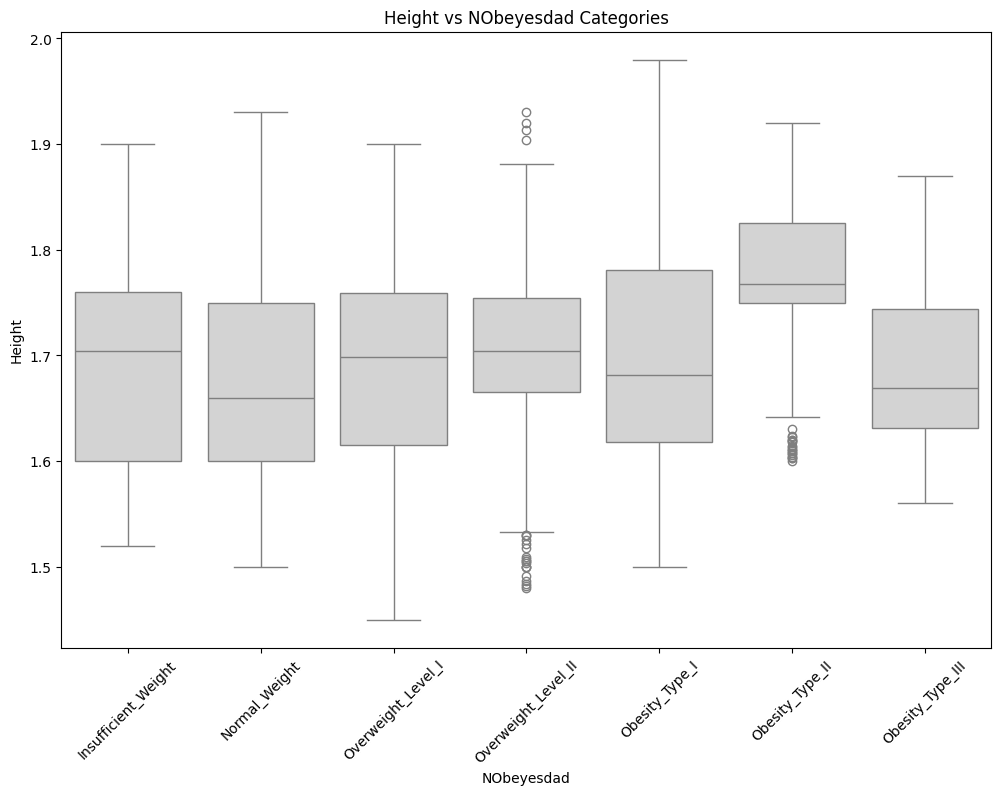

In [35]:
# Plotting with manually specified category order
plt.figure(figsize=(12, 8))
sns.boxplot(x='NObeyesdad', y='Height', data=real_data_new, order=ordered_categories, color='lightgrey')
plt.title('Height vs NObeyesdad Categories')
plt.ylabel('Height')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x800 with 0 Axes>

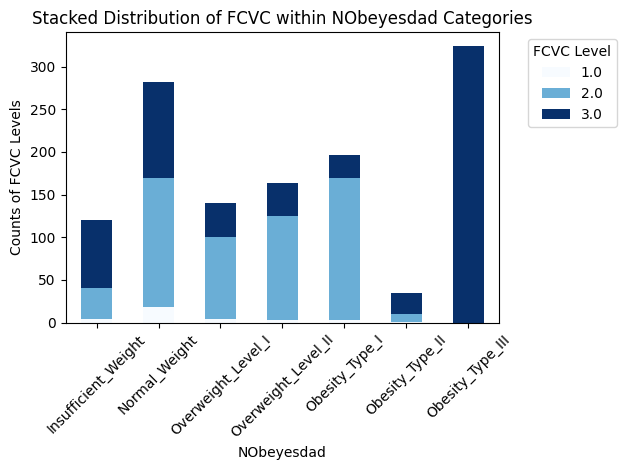

In [36]:
# Filter the DataFrame to include only rows where FCVC has values 1, 2, or 3
filtered_data = real_data_new[real_data_new['FCVC'].isin([1, 2, 3])]

# Create a DataFrame with counts of 'FCVC' for each 'NObeyesdad' category
counts_df_fcvc_stacked = filtered_data.groupby(['NObeyesdad', 'FCVC']).size().unstack(fill_value=0)

# Reorder the DataFrame according to the manually specified order of the NObeyesdad categories
counts_df_fcvc_stacked = counts_df_fcvc_stacked.reindex(ordered_categories)

# Plotting a stacked bar plot for FCVC
plt.figure(figsize=(12, 8))
counts_df_fcvc_stacked.plot(kind='bar', stacked=True, colormap='Blues')
plt.title('Stacked Distribution of FCVC within NObeyesdad Categories')
plt.ylabel('Counts of FCVC Levels')
plt.xticks(rotation=45) 
plt.legend(title='FCVC Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

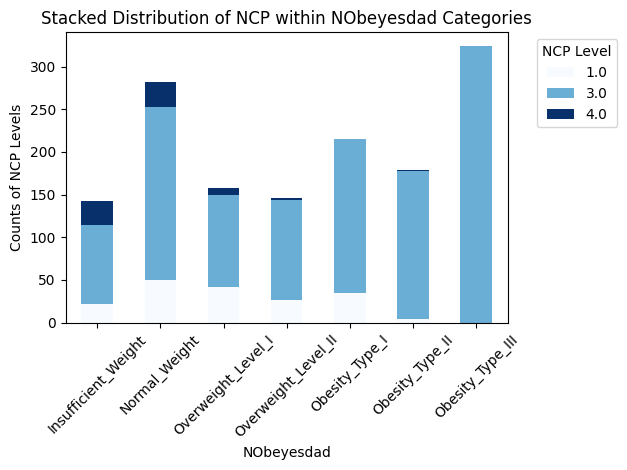

In [37]:
# Filter the DataFrame to include only rows where NCP has values 1, 2, 3 or 4
filtered_data_ncp = real_data_new[real_data_new['NCP'].isin([1, 2, 3, 4])]

# Create a DataFrame with counts of 'FCVC' for each 'NObeyesdad' category
counts_df_ncp_stacked = filtered_data_ncp.groupby(['NObeyesdad', 'NCP']).size().unstack(fill_value=0)

# Reorder the DataFrame according to the manually specified order of the NObeyesdad categories
counts_df_ncp_stacked = counts_df_ncp_stacked.reindex(ordered_categories)

# Plotting a stacked bar plot for NCP
plt.figure(figsize=(12, 8))
counts_df_ncp_stacked.plot(kind='bar', stacked=True, colormap='Blues')
plt.title('Stacked Distribution of NCP within NObeyesdad Categories')
plt.ylabel('Counts of NCP Levels')
plt.xticks(rotation=45)
plt.legend(title='NCP Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

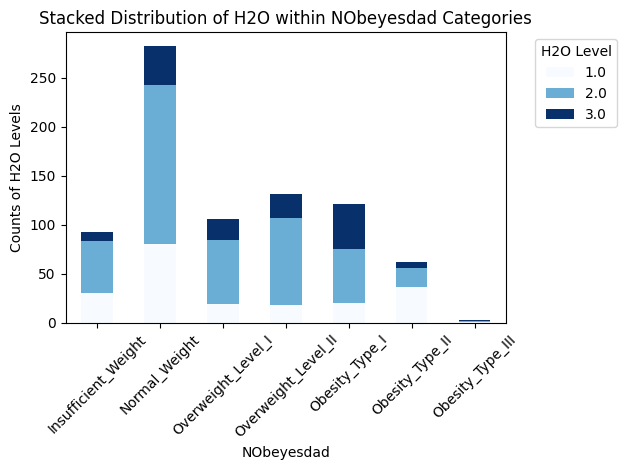

In [40]:
# Filter the DataFrame to include only rows where CH2O has values 1, 2, or 3
filtered_data_ch2O = real_data_new[real_data_new['CH2O'].isin([1, 2, 3])]

# Create a DataFrame with counts of 'CH2O' for each 'NObeyesdad' category
counts_df_ch2O_stacked = filtered_data_ch2O.groupby(['NObeyesdad', 'CH2O']).size().unstack(fill_value=0)

# Reorder the DataFrame according to the manually specified order of the NObeyesdad categories
counts_df_ch2O_stacked = counts_df_ch2O_stacked.reindex(ordered_categories)

# Plotting a stacked bar plot for CH2O
plt.figure(figsize=(12, 8))
counts_df_ch2O_stacked.plot(kind='bar', stacked=True, colormap='Blues')
plt.title('Stacked Distribution of H2O within NObeyesdad Categories')
plt.ylabel('Counts of H2O Levels')
plt.xticks(rotation=45)
plt.legend(title='H2O Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

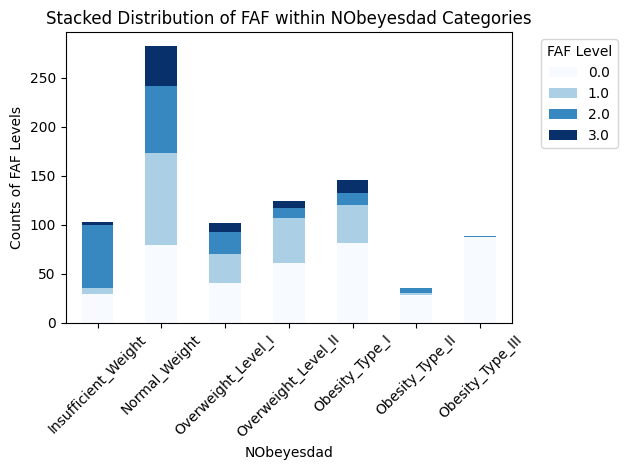

In [41]:
# Filter the DataFrame to include only rows where FAF has values 0, 1, 2, or 3
filtered_data_faf = real_data_new[real_data_new['FAF'].isin([0, 1, 2, 3])]

# Create a DataFrame with counts of 'FAF' for each 'NObeyesdad' category
counts_df_faf_stacked = filtered_data_faf.groupby(['NObeyesdad', 'FAF']).size().unstack(fill_value=0)

# Reorder the DataFrame according to the manually specified order of the NObeyesdad categories
counts_df_faf_stacked = counts_df_faf_stacked.reindex(ordered_categories)

# Plotting a stacked bar plot for FAF
plt.figure(figsize=(12, 8))
counts_df_faf_stacked.plot(kind='bar', stacked=True, colormap='Blues')
plt.title('Stacked Distribution of FAF within NObeyesdad Categories')
plt.ylabel('Counts of FAF Levels')
plt.xticks(rotation=45)
plt.legend(title='FAF Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Statistical Tests

In [44]:
from scipy.stats import f_oneway

numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
anova_results = {}

for col in numerical_cols:
    groups = [group[col].values for name, group in real_data_new.groupby('NObeyesdad')]
    f_stat, p_val = f_oneway(*groups)
    anova_results[col] = p_val

print("ANOVA p-values (lower = significant difference across classes):")
for k, v in anova_results.items():
    print(f"{k}: {v:.4f}")


ANOVA p-values (lower = significant difference across classes):
Age: 0.0000
Height: 0.0000
Weight: 0.0000
FCVC: 0.0000
NCP: 0.0000
CH2O: 0.0000
FAF: 0.0000
TUE: 0.0000


In [45]:
from scipy.stats import chi2_contingency

categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
chi2_results = {}

for col in categorical_cols:
    contingency_table = pd.crosstab(real_data_new[col], real_data_new['NObeyesdad'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results[col] = p

print("\nChi-Square Test p-values (lower = stronger association):")
for k, v in chi2_results.items():
    print(f"{k}: {v:.4f}")



Chi-Square Test p-values (lower = stronger association):
Gender: 0.0000
family_history_with_overweight: 0.0000
FAVC: 0.0000
CAEC: 0.0000
SMOKE: 0.0000
SCC: 0.0000
CALC: 0.0000
MTRANS: 0.0000


In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

# Select only numerical columns (no need to drop NA manually unless your data actually contains NA)
X = real_data_new[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']]

# Add constant for intercept
X = sm.add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame({
    "Feature": X.columns[1:],  # skip 'const'
    "VIF": [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
})

vif_data


,Feature,VIF
0,Age,1.18
1,Height,1.58
2,Weight,1.55
3,FCVC,1.11
4,NCP,1.06
5,CH2O,1.09
6,FAF,1.20
7,TUE,1.11


# Preprocessing

# one hot/true false: gender, family_history_with_overweight, favc, smoke, scc, mtrans
# to int: age, fcvc, ncp, ch20, faf, tue
# standard scaler: age, height, weight,
# label encoding: caec, calc

## Train-test Split

In [344]:
# Separate features and target
X = real_data_new.drop(columns='NObeyesdad')  # Replace 'target' with your actual column name
y = real_data_new['NObeyesdad']               # Replace as needed

# train (60%) and test (40%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42)  

In [345]:
X_train.shape, X_test.shape

((1252, 16), (835, 16))

## Transformation

In [348]:
# Define column groups
one_hot_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']
int_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
scale_cols = ['Height', 'Weight']
label_encode_cols = ['CAEC', 'CALC']
age_col = ['Age']  # handled separately

In [351]:
# Normalize casing in ordinal columns
X_train['CAEC'] = X_train['CAEC'].str.lower()
X_train['CALC'] = X_train['CALC'].str.lower()
X_test['CAEC'] = X_test['CAEC'].str.lower()
X_test['CALC'] = X_test['CALC'].str.lower()

# Recreate ordinal category list
ordinal_order = ['no', 'sometimes', 'frequently', 'always']
ordinal_categories = [ordinal_order, ordinal_order]

In [312]:
"""# FunctionTransformer to round and cast to int
round_int_transformer = FunctionTransformer(lambda x: np.round(x).astype(int))

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# Create a pipeline: first round, then scale
round_then_scale_pipeline = Pipeline(steps=[
    ('round', FunctionTransformer(np.round, validate=False)),
    ('scale', StandardScaler())
])
"""

In [357]:
# Transformer to just round (for other int columns)
round_only = FunctionTransformer(np.round, validate=False)

# Pipeline: round then scale (for Age only)
round_then_scale = Pipeline([
    ('round', FunctionTransformer(np.round, validate=False)),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(sparse_output=False, drop='if_binary'), one_hot_cols),
    ('scale', StandardScaler(), ['Height', 'Weight']),  # don't include 'Age' here
    ('ordinal', OrdinalEncoder(categories=ordinal_categories), label_encode_cols),
    ('round_only', round_only, int_cols),               # other int columns
    ('round_scale_age', round_then_scale, age_col)      # Age: round + scale
], remainder='passthrough')


# Fit on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Final column names
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(one_hot_cols)
final_column_names = (
    list(onehot_feature_names) +
    scale_cols +
    label_encode_cols +
    int_cols +  # Add the rounded integer columns
    [col for col in X_train.columns if col not in (one_hot_cols + scale_cols + label_encode_cols + int_cols)]
)

# Convert to DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=final_column_names)
X_test_df = pd.DataFrame(X_test_processed, columns=final_column_names)

In [360]:
X_train_df

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Height,Weight,CAEC,CALC,FCVC,NCP,CH2O,FAF,TUE,Age
0,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.83,0.74,1.00,1.00,3.00,3.00,2.00,2.00,1.00,0.27
1,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.30,2.10,1.00,1.00,3.00,3.00,3.00,2.00,1.00,-1.00
2,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.53,-1.13,2.00,0.00,3.00,3.00,2.00,0.00,1.00,-1.16
3,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-1.61,-1.59,2.00,0.00,2.00,3.00,2.00,1.00,1.00,-1.32
4,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.53,-0.34,2.00,2.00,2.00,3.00,2.00,0.00,2.00,-0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1247,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.81,0.91,1.00,1.00,3.00,3.00,3.00,0.00,0.00,0.27
1248,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.21,-1.28,1.00,1.00,2.00,3.00,2.00,0.00,2.00,-1.00
1249,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.07,-0.56,1.00,1.00,2.00,3.00,2.00,3.00,0.00,-1.00
1250,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.42,1.85,1.00,1.00,3.00,3.00,2.00,1.00,1.00,-0.52


In [363]:
X_test_df

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Height,Weight,CAEC,CALC,FCVC,NCP,CH2O,FAF,TUE,Age
0,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.47,0.95,1.00,1.00,3.00,3.00,3.00,0.00,0.00,0.27
1,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,-0.90,-0.83,1.00,0.00,2.00,1.00,1.00,0.00,1.00,-1.32
2,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.19,-0.06,1.00,1.00,3.00,3.00,3.00,0.00,1.00,-0.20
3,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.63,0.95,1.00,1.00,2.00,3.00,2.00,0.00,0.00,0.91
4,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.23,-1.30,1.00,1.00,2.00,3.00,2.00,0.00,2.00,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-0.08,-0.57,1.00,1.00,3.00,3.00,2.00,1.00,1.00,1.07
831,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.54,1.27,1.00,1.00,3.00,3.00,3.00,1.00,1.00,0.43
832,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,-2.15,-0.45,2.00,1.00,2.00,3.00,1.00,0.00,0.00,2.02
833,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-1.01,0.69,1.00,1.00,3.00,3.00,2.00,0.00,1.00,0.27


# Modeling

## Baseline

In [366]:
# Now run the LazyClassifier code
from lazypredict.Supervised import LazyClassifier

lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lazy_clf.fit(X_train_processed, X_test_processed, y_train, y_test)

# Show the results
models

  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 1252, number of used features: 18
[LightGBM] [Info] Start training from score -2.057324
[LightGBM] [Info] Start training from score -2.002599
[LightGBM] [Info] Start training from score -1.780639
[LightGBM] [Info] Start training from score -1.950714
[LightGBM] [Info] Start training from score -1.864639
[LightGBM] [Info] Start training from score -2.020510
[LightGBM] [Info] Start training from score -1.973442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.96,0.96,None,0.96,1.43
BaggingClassifier,0.93,0.93,None,0.93,0.08
RandomForestClassifier,0.93,0.93,None,0.93,0.29
DecisionTreeClassifier,0.92,0.91,None,0.92,0.09
ExtraTreesClassifier,0.92,0.91,None,0.92,0.21
LinearDiscriminantAnalysis,0.89,0.89,None,0.89,0.62
LogisticRegression,0.87,0.87,None,0.87,1.91
SVC,0.84,0.84,None,0.84,0.14
NuSVC,0.84,0.83,None,0.84,0.40


## Stacking Model

In [68]:
# Define base models
base_models = [
    ('ada', AdaBoostClassifier(n_estimators=1000, random_state=0)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=0)),
    ('svc', SVC(kernel='linear', probability=True, random_state=0))
]

# Define the meta-model
meta_model = RandomForestClassifier(n_estimators=1000, random_state=0)

# Create the stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=10
)

stacking_classifier.fit(X_train_processed, y_train)
#stacking_classifier.score(X_test_processed, y_test)

StackingClassifier(cv=10,
                   estimators=[('ada',
                                AdaBoostClassifier(n_estimators=1000,
                                                   random_state=0)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('svc',
                                SVC(kernel='linear', probability=True,
                                    random_state=0))],
                   final_estimator=RandomForestClassifier(n_estimators=1000,
                                                          random_state=0))

Classification Report (Test Data):
                      precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99       107
      Normal_Weight       0.95      0.94      0.95       113
     Obesity_Type_I       1.00      0.97      0.99       140
    Obesity_Type_II       0.98      1.00      0.99       119
   Obesity_Type_III       1.00      0.99      1.00       130
 Overweight_Level_I       0.95      0.92      0.94       110
Overweight_Level_II       0.95      1.00      0.97       116

           accuracy                           0.97       835
          macro avg       0.97      0.97      0.97       835
       weighted avg       0.98      0.97      0.97       835



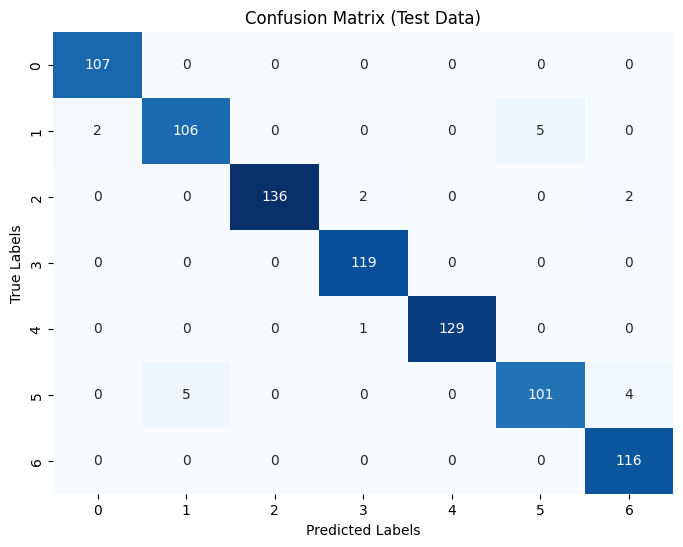

In [69]:
test_predictions = stacking_classifier.predict(X_test_processed)

classification_report_test = classification_report(y_test, test_predictions)

print("Classification Report (Test Data):\n", classification_report_test)

confusion_matrix_test = confusion_matrix(y_test, test_predictions)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Hyperparameter Tuning TODO: improve search space

In [369]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train_processed, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 1252, number of used features: 18
[LightGBM] [Info] Start training from score -2.057324
[LightGBM] [Info] Start training from score -2.002599
[LightGBM] [Info] Start training from score -1.780639
[LightGBM] [Info] Start training from score -1.950714
[LightGBM] [Info] Start training from score -1.864639
[LightGBM] [Info] Start training from score -2.020510
[LightGBM] [Info] Start training from score -1.973442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

LGBMClassifier()

In [131]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import classification_report

# Parameter space (more efficient + avoids bad values)
param_dist = {
    'n_estimators': randint(100, 500),                 # avoid too many trees for early runs
    'learning_rate': uniform(0.01, 0.2),               # smaller range = less noisy search
    'num_leaves': randint(20, 100),                    # good balance
    'max_depth': randint(3, 12),                       # deeper trees risk overfitting
    'min_child_samples': randint(5, 50),
    'subsample': uniform(0.6, 0.4),                    # range: 0.6–1.0
    'colsample_bytree': uniform(0.6, 0.4),             # range: 0.6–1.0
    'boosting_type': ['gbdt', 'dart'],                 # 'goss' not supported with subsample
    'reg_alpha': uniform(0, 1.0),                      # L1 regularization
    'reg_lambda': uniform(0, 1.0),                     # L2 regularization
}

# Initialize model
lgbm = LGBMClassifier(random_state=42, n_jobs=-1)

# RandomizedSearchCV setup
tuned_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,                        # slightly more iterations
    cv=10,
    scoring='accuracy',              # use 'f1_macro' for class imbalance
    verbose=0,
    random_state=42,
    n_jobs=-1
)

# Fit search
tuned_lgbm.fit(X_train_processed, y_train)

# Best params and score
print("✅ Best Parameters:", tuned_lgbm.best_params_)
print("✅ Best CV Accuracy:", tuned_lgbm.best_score_)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -


📊 Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.96      0.98      0.97       107
      Normal_Weight       0.88      0.91      0.90       113
     Obesity_Type_I       0.98      0.98      0.98       140
    Obesity_Type_II       1.00      0.98      0.99       119
   Obesity_Type_III       1.00      0.99      1.00       130
 Overweight_Level_I       0.92      0.85      0.89       110
Overweight_Level_II       0.94      0.98      0.96       116

           accuracy                           0.96       835
          macro avg       0.96      0.95      0.95       835
       weighted avg       0.96      0.96      0.96       835



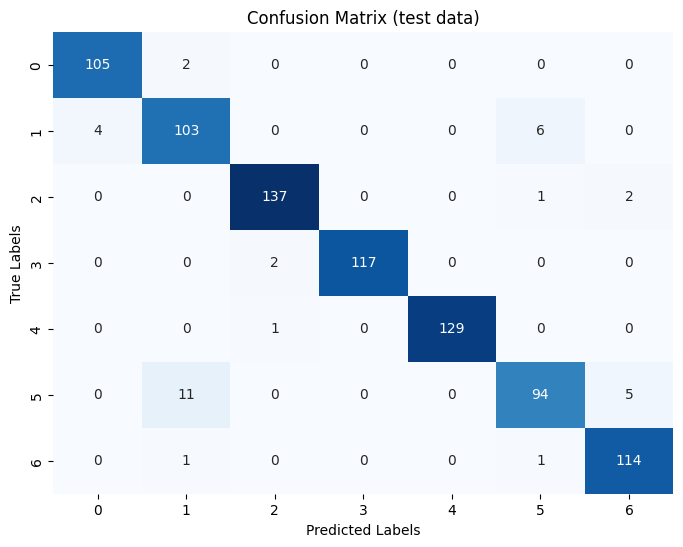

In [132]:
# Evaluate on test set
y_pred = tuned_lgbm.predict(X_test_processed)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

confusion_matrix_ft = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_ft, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (test data)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#  Explainable AI TODO: XAI on tuned model

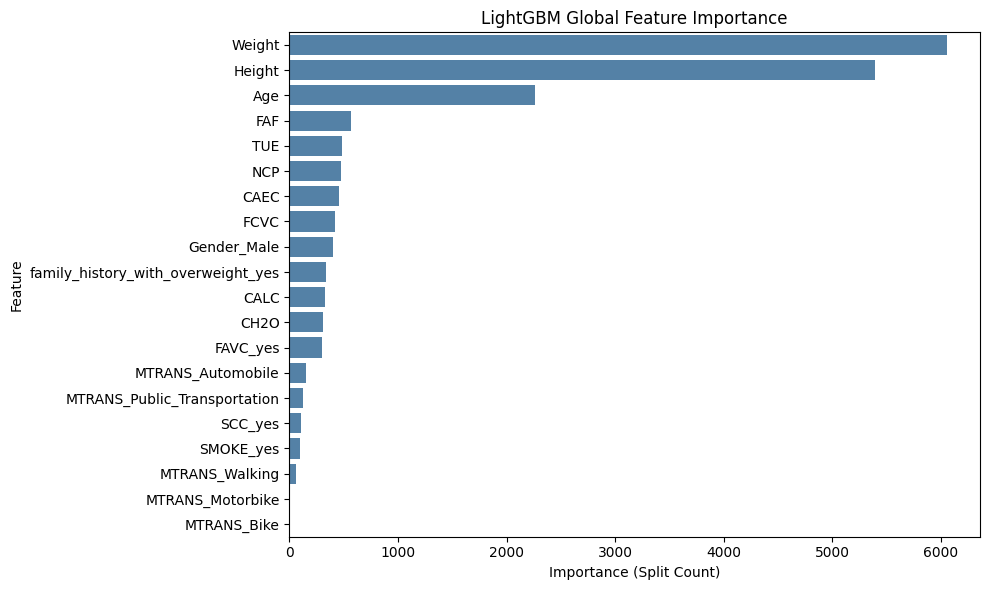

In [372]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create importance dataframe
importances = lgbm.feature_importances_
feature_names = X_train_df.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Ensure uniqueness and proper types
importance_df['Feature'] = importance_df['Feature'].astype(str)
#importance_df = importance_df.drop_duplicates(subset='Feature')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')
plt.title('LightGBM Global Feature Importance')
plt.xlabel('Importance (Split Count)')
plt.tight_layout()
plt.show()


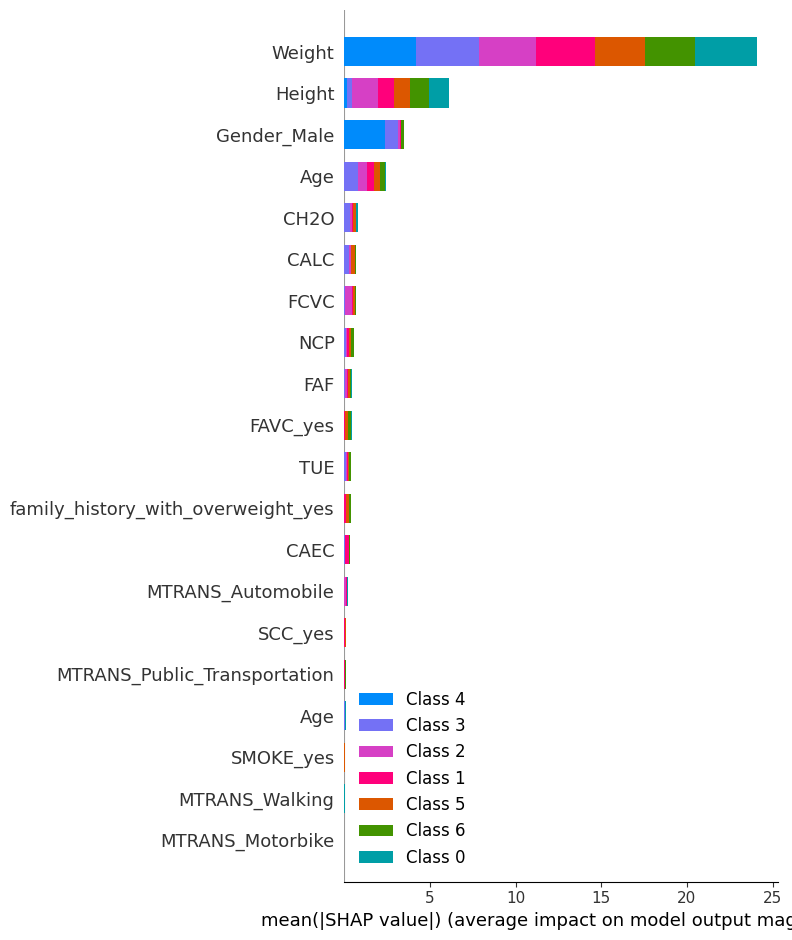

In [74]:
# TODO:Explain for each class

explainer = shap.Explainer(lgbm)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [68]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train_df.values,
                                  feature_names=X_train_df.columns,
                                  class_names=np.unique(y_train),
                                  discretize_continuous=True)

i = 0  # index of the sample to explain
exp = explainer.explain_instance(X_test_df.iloc[i].values, lgbm.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)


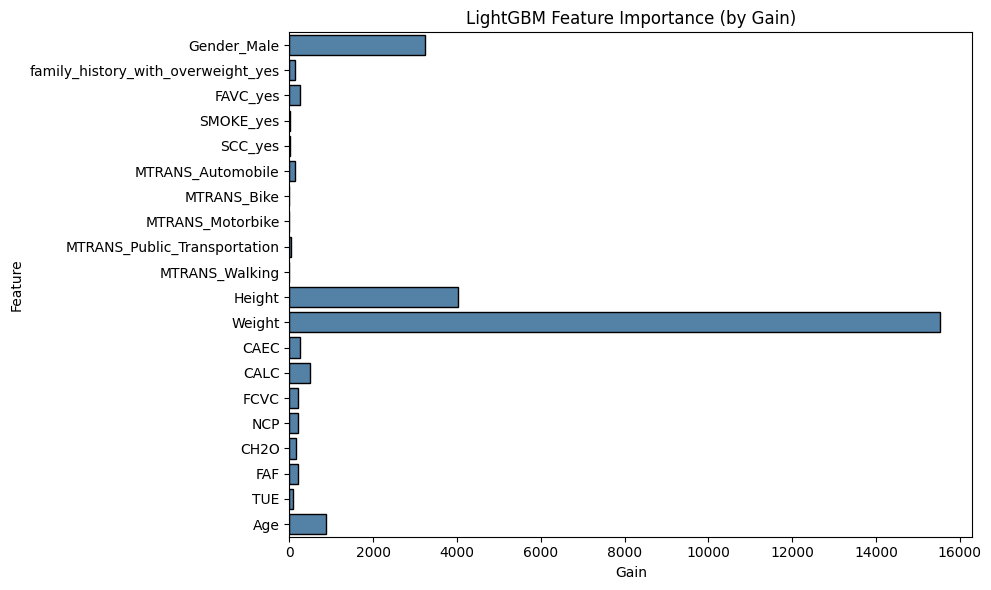

In [375]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure values are clean and numeric
gain_importances = lgbm.booster_.feature_importance(importance_type='gain')
feature_names = list(X_train_df.columns)

# Clean DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain': gain_importances
}).drop_duplicates(subset='Feature')

# Force numeric and sort
importance_df['Gain'] = pd.to_numeric(importance_df['Gain'], errors='coerce')
#importance_df = importance_df.sort_values(by='Gain', ascending=False)

# Plot cleanly
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Gain', y='Feature', color='steelblue', edgecolor='black')
plt.title('LightGBM Feature Importance (by Gain)')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()


<hr>

# Synthetic Data Augmentation

In [378]:
# Load synthetic data
synth_df = pd.read_csv("/work/synth.csv")

# Drop 'id' column if it exists
synth_df.drop(columns=['id'], inplace=True)

# Preview data
synth_df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,24.44,1.70,81.67,yes,yes,2.00,2.98,Sometimes,no,2.76,no,0.00,0.98,Sometimes,Public_Transportation,Overweight_Level_II
1,Female,18.00,1.56,57.00,yes,yes,2.00,3.00,Frequently,no,2.00,no,1.00,1.00,no,Automobile,Normal_Weight
2,Female,18.00,1.71,50.17,yes,yes,1.88,1.41,Sometimes,no,1.91,no,0.87,1.67,no,Public_Transportation,Insufficient_Weight
3,Female,20.95,1.71,131.27,yes,yes,3.00,3.00,Sometimes,no,1.67,no,1.47,0.78,Sometimes,Public_Transportation,Obesity_Type_III
4,Male,31.64,1.91,93.80,yes,yes,2.68,1.97,Sometimes,no,1.98,no,1.97,0.93,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,Male,25.14,1.77,114.19,yes,yes,2.92,3.00,Sometimes,no,2.15,no,1.33,0.20,Sometimes,Public_Transportation,Obesity_Type_II
20754,Male,18.00,1.71,50.00,no,yes,3.00,4.00,Frequently,no,1.00,no,2.00,1.00,Sometimes,Public_Transportation,Insufficient_Weight
20755,Male,20.10,1.82,105.58,yes,yes,2.41,3.00,Sometimes,no,2.00,no,1.16,1.20,no,Public_Transportation,Obesity_Type_II
20756,Male,33.85,1.70,83.52,yes,yes,2.67,1.97,Sometimes,no,2.14,no,0.00,0.97,no,Automobile,Overweight_Level_II


In [381]:
real_data_new

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.00,1.62,64.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,0.00,1.00,no,Public_Transportation,Normal_Weight
1,Female,21.00,1.52,56.00,yes,no,3.00,3.00,Sometimes,yes,3.00,yes,3.00,0.00,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.00,1.80,77.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,2.00,1.00,Frequently,Public_Transportation,Normal_Weight
3,Male,27.00,1.80,87.00,no,no,3.00,3.00,Sometimes,no,2.00,no,2.00,0.00,Frequently,Walking,Overweight_Level_I
4,Male,22.00,1.78,89.80,no,no,2.00,1.00,Sometimes,no,2.00,no,0.00,0.00,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,Female,20.98,1.71,131.41,yes,yes,3.00,3.00,Sometimes,no,1.73,no,1.68,0.91,Sometimes,Public_Transportation,Obesity_Type_III
2083,Female,21.98,1.75,133.74,yes,yes,3.00,3.00,Sometimes,no,2.01,no,1.34,0.60,Sometimes,Public_Transportation,Obesity_Type_III
2084,Female,22.52,1.75,133.69,yes,yes,3.00,3.00,Sometimes,no,2.05,no,1.41,0.65,Sometimes,Public_Transportation,Obesity_Type_III
2085,Female,24.36,1.74,133.35,yes,yes,3.00,3.00,Sometimes,no,2.85,no,1.14,0.59,Sometimes,Public_Transportation,Obesity_Type_III


In [382]:
synth_df_x = synth_df.drop(columns='NObeyesdad')
synth_df_y = synth_df['NObeyesdad']               # Replace as needed

In [385]:
# Normalize casing in ordinal columns
synth_df_x['CAEC'] = synth_df_x['CAEC'].str.lower()
synth_df_x['CALC'] = synth_df_x['CALC'].str.lower()

In [388]:
# Fit on training data
synth_df_x_processed = preprocessor.fit_transform(synth_df_x)

# Final column names
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(one_hot_cols)
final_column_names = (
    list(onehot_feature_names) +
    scale_cols +
    label_encode_cols +
    int_cols +  # Add the rounded integer columns
    [col for col in X_train.columns if col not in (one_hot_cols + scale_cols + label_encode_cols + int_cols)]
)

# Convert to DataFrame
synth_df_processed = pd.DataFrame(synth_df_x_processed, columns=final_column_names)

In [391]:
synth_df_processed

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Height,Weight,CAEC,CALC,FCVC,NCP,CH2O,FAF,TUE,Age
0,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.00,-0.24,1.00,1.00,2.00,3.00,3.00,0.00,1.00,0.03
1,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-1.61,-1.17,2.00,0.00,2.00,3.00,2.00,1.00,1.00,-1.03
2,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.13,-1.43,1.00,0.00,2.00,1.00,2.00,1.00,2.00,-1.03
3,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.12,1.64,1.00,1.00,3.00,3.00,2.00,1.00,1.00,-0.50
4,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.45,0.22,1.00,1.00,3.00,2.00,2.00,2.00,1.00,1.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.76,1.00,1.00,1.00,3.00,3.00,2.00,1.00,0.00,0.20
20754,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.11,-1.44,2.00,1.00,3.00,4.00,1.00,2.00,1.00,-1.03
20755,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.37,0.67,1.00,0.00,2.00,3.00,2.00,1.00,1.00,-0.68
20756,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-0.00,-0.17,1.00,0.00,3.00,2.00,2.00,0.00,1.00,1.78


## Similarity Check

# check if augmented data is also high similairity to real test data, if so remove

In [394]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.neighbors import NearestNeighbors

Filtered synthetic samples: 16350


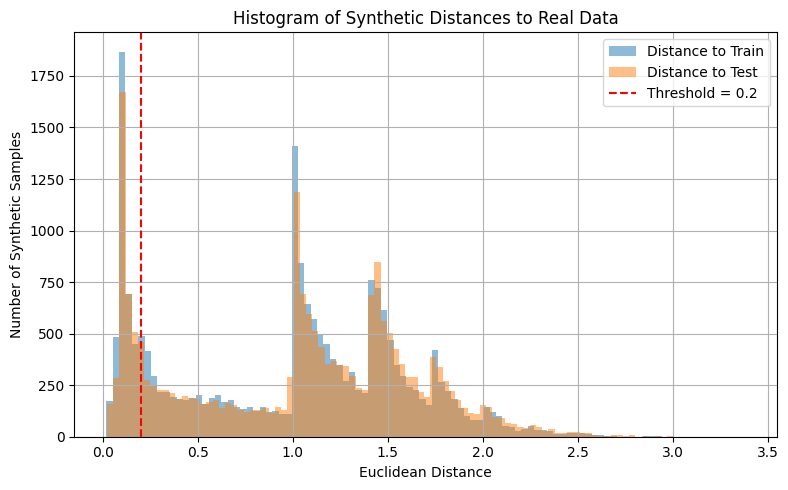

In [395]:
# --- Step 2: Similarity Check ---
nn_train = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(X_train_processed)
nn_test = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(X_test_processed)

dist_to_train, _ = nn_train.kneighbors(synth_df_processed)
dist_to_test, _ = nn_test.kneighbors(synth_df_processed)

# --- Step 3: Filtering ---
threshold = 0.2
mask = (dist_to_train.ravel() > threshold) & (dist_to_test.ravel() > threshold)

# --- Step 4: Apply mask to get final processed X and y ---
X_filtered_synthetic = synth_df_processed.loc[mask].reset_index(drop=True)
y_filtered_synthetic = synth_df_y.loc[mask].reset_index(drop=True)

print(f"Filtered synthetic samples: {len(X_filtered_synthetic)}")

# --- Step 5: Visualization ---
plt.figure(figsize=(8, 5))
plt.hist(dist_to_train.ravel(), bins=100, alpha=0.5, label='Distance to Train')
plt.hist(dist_to_test.ravel(), bins=100, alpha=0.5, label='Distance to Test')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title("Histogram of Synthetic Distances to Real Data")
plt.xlabel("Euclidean Distance")
plt.ylabel("Number of Synthetic Samples")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

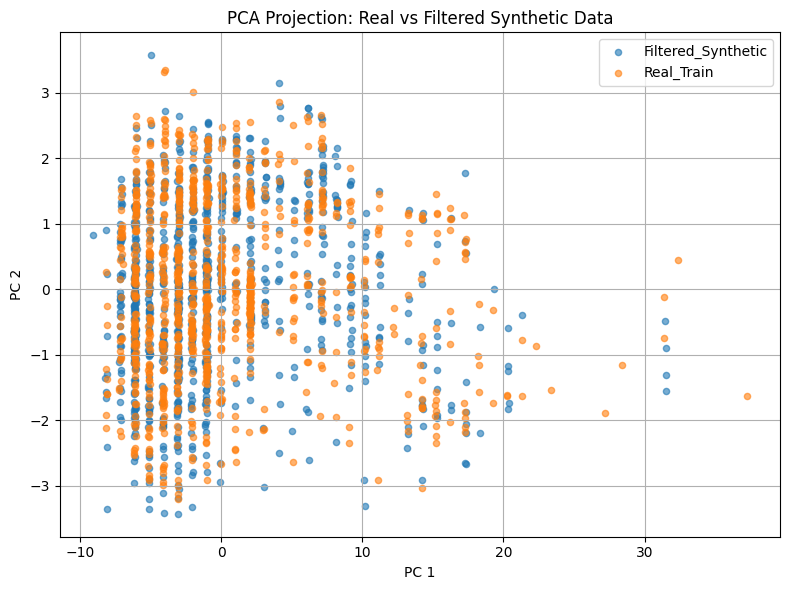

In [206]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce thread usage for OpenBLAS
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

# Subsample (if needed)
max_samples = 1000
real_sample = X_train_processed[:max_samples]
synthetic_sample = X_filtered_synthetic[:max_samples]

# Combine
combined_X = np.vstack([real_sample, synthetic_sample])
labels = np.array(['Real_Train'] * len(real_sample) + ['Filtered_Synthetic'] * len(synthetic_sample))

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(combined_X)

# Plot
plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.6, s=20)

plt.title("PCA Projection: Real vs Filtered Synthetic Data")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [398]:
X_filtered_synthetic

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Height,Weight,CAEC,CALC,FCVC,NCP,CH2O,FAF,TUE,Age
0,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.00,-0.24,1.00,1.00,2.00,3.00,3.00,0.00,1.00,0.03
1,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-1.61,-1.17,2.00,0.00,2.00,3.00,2.00,1.00,1.00,-1.03
2,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.13,-1.43,1.00,0.00,2.00,1.00,2.00,1.00,2.00,-1.03
3,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.45,0.22,1.00,1.00,3.00,2.00,2.00,2.00,1.00,1.43
4,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.55,-1.38,1.00,1.00,3.00,3.00,2.00,2.00,1.00,-1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16345,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.76,1.00,1.00,1.00,3.00,3.00,2.00,1.00,0.00,0.20
16346,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.11,-1.44,2.00,1.00,3.00,4.00,1.00,2.00,1.00,-1.03
16347,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.37,0.67,1.00,0.00,2.00,3.00,2.00,1.00,1.00,-0.68
16348,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-0.00,-0.17,1.00,0.00,3.00,2.00,2.00,0.00,1.00,1.78


In [401]:
y_filtered_synthetic

0        Overweight_Level_II
1              Normal_Weight
2        Insufficient_Weight
3        Overweight_Level_II
4        Insufficient_Weight
                ...         
16345        Obesity_Type_II
16346    Insufficient_Weight
16347        Obesity_Type_II
16348    Overweight_Level_II
16349        Obesity_Type_II
Name: NObeyesdad, Length: 16350, dtype: object

## Gowers Distance

In [ ]:
!pip install gower

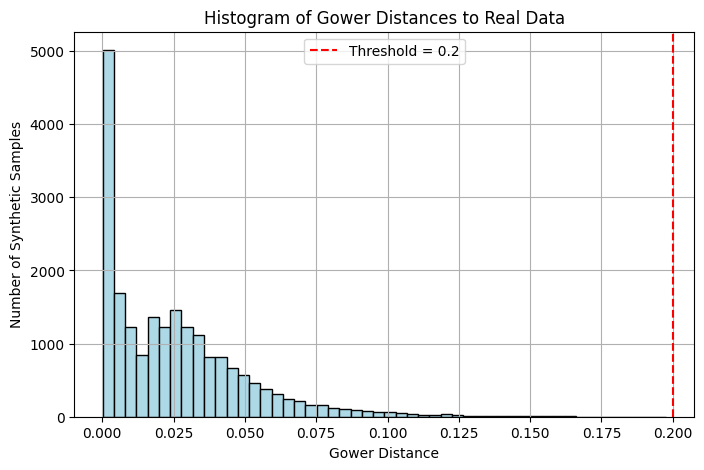

In [197]:
# Convert processed NumPy arrays back to DataFrames
synth_df_x_processed_df_gower = pd.DataFrame(synth_df_x_processed, columns=final_column_names)
X_train_processed_df_gower = pd.DataFrame(X_train_processed, columns=final_column_names)

# Then compute Gower distance
import gower

gower_distances = gower.gower_matrix(synth_df_x_processed_df_gower, X_train_processed_df_gower)
min_distances = gower_distances.min(axis=1)

# Filter synthetic samples
threshold = 0.2
mask = min_distances > threshold
X_filtered_synthetic_gower = synth_df_x_processed_df_gower.loc[mask].reset_index(drop=True)
y_filtered_synthetic_gower = synth_df_y.loc[mask].reset_index(drop=True)

# Plot
plt.figure(figsize=(8, 5))
plt.hist(min_distances, bins=50, color='lightblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title("Histogram of Gower Distances to Real Data")
plt.xlabel("Gower Distance")
plt.ylabel("Number of Synthetic Samples")
plt.legend()
plt.grid(True)
plt.show()

## Retrain with Data Augmentation

In [404]:
X_filtered_synthetic

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Height,Weight,CAEC,CALC,FCVC,NCP,CH2O,FAF,TUE,Age
0,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.00,-0.24,1.00,1.00,2.00,3.00,3.00,0.00,1.00,0.03
1,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-1.61,-1.17,2.00,0.00,2.00,3.00,2.00,1.00,1.00,-1.03
2,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.13,-1.43,1.00,0.00,2.00,1.00,2.00,1.00,2.00,-1.03
3,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.45,0.22,1.00,1.00,3.00,2.00,2.00,2.00,1.00,1.43
4,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.55,-1.38,1.00,1.00,3.00,3.00,2.00,2.00,1.00,-1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16345,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.76,1.00,1.00,1.00,3.00,3.00,2.00,1.00,0.00,0.20
16346,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.11,-1.44,2.00,1.00,3.00,4.00,1.00,2.00,1.00,-1.03
16347,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.37,0.67,1.00,0.00,2.00,3.00,2.00,1.00,1.00,-0.68
16348,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-0.00,-0.17,1.00,0.00,3.00,2.00,2.00,0.00,1.00,1.78


In [407]:
# Combine filtered synthetic with real train
X_augmented = pd.concat([X_train_df, X_filtered_synthetic], axis=0).reset_index(drop=True)
y_augmented = pd.concat([y_train, y_filtered_synthetic], axis=0).reset_index(drop=True)

# Step 2: Set up nested CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Step 3: Define model (tune in inner loop if needed)
model = LGBMClassifier()

# Step 4: Run nested CV
scores = cross_val_score(model, X_augmented, y_augmented, cv=outer_cv, scoring='accuracy')

# Output results
print("Nested CV Accuracy Scores:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Std Deviation:", np.std(scores))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] [Info] Number of data points in the train set: 14081, number of used features: 20
[LightGBM] [Info] Start training from score -1.943215
[LightGBM] [Info] Start training from score -1.692397
[LightGBM] [Info] Start training from score -1.821968
[LightGBM] [Info] Start training from score -1.860012
[LightGBM] [Info] Start training from score -2.729296
[LightGBM] [Info] Start training from score -1.950180
[LightGBM] [Info] Start training from score -1.911978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] 

In [ ]:
# TODO: apply normal CV with same config from original

In [239]:
X_augmented

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,...,Height,Weight,CAEC,CALC,Age,FCVC,NCP,CH2O,FAF,TUE
0,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.83,0.74,1.00,1.00,26.00,3.00,3.00,2.00,2.00,1.00
1,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,1.30,2.10,1.00,1.00,18.00,3.00,3.00,3.00,2.00,1.00
2,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.53,-1.13,2.00,0.00,17.00,3.00,3.00,2.00,0.00,1.00
3,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,-1.61,-1.59,2.00,0.00,16.00,2.00,3.00,2.00,1.00,1.00
4,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,...,0.53,-0.34,2.00,2.00,21.00,2.00,3.00,2.00,0.00,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18189,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.76,1.00,1.00,1.00,25.00,3.00,3.00,2.00,1.00,0.00
18190,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.11,-1.44,2.00,1.00,18.00,3.00,4.00,1.00,2.00,1.00
18191,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,1.37,0.67,1.00,0.00,20.00,2.00,3.00,2.00,1.00,1.00
18192,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,-0.00,-0.17,1.00,0.00,34.00,3.00,2.00,2.00,0.00,1.00


In [410]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred = cross_val_predict(LGBMClassifier(), X_augmented, y_augmented, cv=5)
print(classification_report(y_augmented, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 596
[LightGBM] [Info] Number of data points in the train set: 14081, number of used features: 20
[LightGBM] [Info] Start training from score -1.943215
[LightGBM] [Info] Start training from score -1.692397
[LightGBM] [Info] Start training from score -1.821968
[LightGBM] [Info] Start training from score -1.860012
[LightGBM] [Info] Start training from score -2.729296
[LightGBM] [Info] Start training from score -1.950180
[LightGBM] [Info] Start training from score -1.911978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a441f35e-4b4c-4c50-b56a-1aea6b800ed8' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>